# Training & Camera Testing — Color Identification

**Model:** ResNet-50 (ImageNet-pretrained) → 13-class softmax head.
**Loss:** KL Divergence on soft label distributions.
**Optimizer:** AdamW (lr=1e-4) + ReduceLROnPlateau.

**Runtime:** Google Colab (free tier, T4 GPU) via VS Code extension.

---

### How the shared Drive folder works

Set `DRIVE_FOLDER_ID` to the shared Google Drive folder ID.  
The folder must contain:
- **a `.zip` file** — the dataset zip (any name ending in `.zip`)
- **a `checkpoints/` sub-folder** — created automatically on first run

On every run Cell 1 will:
1. Authenticate with Google (Colab one-time prompt).
2. List the shared folder; find the `.zip` and the `checkpoints/` sub-folder.
3. Download any existing `latest.pth` / `best.pth` so training resumes from the latest epoch.
4. Download and extract the dataset zip (skipped if already extracted).

After each epoch the training cell **uploads** the updated checkpoints back to the shared Drive folder, so any subsequent Colab session — on any account — picks up exactly where the previous one left off.


In [5]:
import zipfile, os, io, torch, logging as _logging

# ── Configuration ────────────────────────────────────────────────────────────
# Shared Google Drive folder (anyone with link can edit).
# Must contain: one .zip dataset file  +  a "checkpoints/" sub-folder
# (the sub-folder is created automatically on the first run).
DRIVE_FOLDER_ID = "1GwLV_ZFaeSw0w59OU1ToCGuG5EkHgk5f"
LOCAL_EXTRACT   = "/content/dataset"
CHECKPOINT_DIR  = "/content/checkpoints"

COLOR_CLASSES = [
    "red", "orange", "yellow", "green", "blue",
    "violet", "purple", "white", "gray", "black",
    "pink", "brown", "olive",
]

# ── Authenticate (Colab one-time prompt) ─────────────────────────────────────
from google.colab import auth as _colab_auth
_colab_auth.authenticate_user()

import subprocess
subprocess.run(["pip", "install", "-q", "gdown"], check=True)
import gdown
from googleapiclient.discovery import build as _build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

_drive = _build("drive", "v3")
_logging.getLogger("google_auth_httplib2").setLevel(_logging.ERROR)

def _list_folder(folder_id):
    items = []
    page_token = None
    while True:
        resp = _drive.files().list(
            q=f"'{folder_id}' in parents and trashed=false",
            fields="nextPageToken, files(id,name,mimeType)",
            pageToken=page_token,
        ).execute()
        items.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            break
    return items

def _download_file(file_id, local_path):
    request = _drive.files().get_media(fileId=file_id)
    with open(local_path, "wb") as fh:
        dl = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = dl.next_chunk()

# ── Locate or create the checkpoints sub-folder in Drive ─────────────────────
_folder_contents = _list_folder(DRIVE_FOLDER_ID)

_ckpt_folder_entry = next(
    (f for f in _folder_contents
     if f["name"] == "checkpoints"
     and f["mimeType"] == "application/vnd.google-apps.folder"),
    None,
)
if _ckpt_folder_entry is None:
    print("Creating 'checkpoints' folder in Drive...")
    _ckpt_folder_entry = _drive.files().create(
        body={
            "name": "checkpoints",
            "mimeType": "application/vnd.google-apps.folder",
            "parents": [DRIVE_FOLDER_ID],
        },
        fields="id,name",
    ).execute()
    print("  Created.")
else:
    print("Found 'checkpoints' folder in Drive.")

DRIVE_CKPT_FOLDER_ID = _ckpt_folder_entry["id"]
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Download existing checkpoints → enables resume across accounts ────────────
_drive_ckpt_files = {f["name"]: f["id"] for f in _list_folder(DRIVE_CKPT_FOLDER_ID)}
if _drive_ckpt_files:
    for _name, _fid in _drive_ckpt_files.items():
        _local = os.path.join(CHECKPOINT_DIR, _name)
        print(f"Downloading checkpoint: {_name} ...")
        _download_file(_fid, _local)
    print("Checkpoints ready.")
else:
    print("No existing checkpoints in Drive — will start fresh.")

# ── Download & extract dataset zip (skip if already extracted) ────────────────
def _find_file(root, name):
    for dirpath, _, filenames in os.walk(root):
        if name in filenames:
            return os.path.join(dirpath, name)
    return None

csv_found = _find_file(LOCAL_EXTRACT, "labels.csv") if os.path.exists(LOCAL_EXTRACT) else None

if csv_found is None:
    _zip_entry = next(
        (f for f in _folder_contents if f["name"].endswith(".zip")), None
    )
    if _zip_entry is None:
        raise FileNotFoundError("No .zip file found in the shared Drive folder!")
    print(f"Downloading dataset: {_zip_entry['name']} ...")
    zip_path = "/content/generated_dataset.zip"
    gdown.download(id=_zip_entry["id"], output=zip_path, quiet=False)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(LOCAL_EXTRACT)
    os.remove(zip_path)
    csv_found = _find_file(LOCAL_EXTRACT, "labels.csv")
    if csv_found is None:
        raise FileNotFoundError("labels.csv not found anywhere inside the zip!")
    print("Done.")
else:
    print("Dataset already extracted.")

CSV_PATH = csv_found
IMG_DIR  = os.path.join(os.path.dirname(csv_found), "images")
print(f"CSV : {CSV_PATH}")
print(f"Imgs: {IMG_DIR}  ({len(os.listdir(IMG_DIR))} files)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU available, using CPU.")


Found 'checkpoints' folder in Drive.
Checkpoints ready.
Dataset already extracted.
CSV : /content/dataset/generated/labels.csv
Imgs: /content/dataset/generated/images  (22000 files)
GPU: Tesla T4


## Dataset, Model & DataLoaders

In [6]:
import random
import pandas as pd
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
import PIL.Image


class ColorDataset(Dataset):
    """Reads images + soft label vectors from a CSV / image directory."""

    def __init__(self, csv_path, img_dir, split, color_classes, transform=None):
        df = pd.read_csv(csv_path)
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.img_dir = img_dir
        self.color_classes = color_classes
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(self.img_dir, row["filename"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor([row[c] for c in self.color_classes], dtype=torch.float32)
        return img, label


class RandomColorTemperature:
    """Simulate warm/cool lighting by scaling R and B channels in opposite directions.

    A single temperature factor t is sampled uniformly from [-strength, +strength].
    Positive t = warm (boost R, reduce B); negative t = cool (reduce R, boost B).
    This keeps the shift correlated, unlike ColorJitter which varies channels independently.
    """
    def __init__(self, strength=0.3):
        self.strength = strength

    def __call__(self, img):
        arr = np.array(img, dtype=np.float32)
        t = random.uniform(-self.strength, self.strength)
        arr[:, :, 0] = np.clip(arr[:, :, 0] * (1.0 + t), 0, 255)   # R  (warm = boost)
        arr[:, :, 2] = np.clip(arr[:, :, 2] * (1.0 - t), 0, 255)   # B  (warm = reduce)
        return PIL.Image.fromarray(arr.astype(np.uint8))


def create_model(num_classes=13, dropout=0.4):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


# ── Transforms (ImageNet normalisation) ──────────────────────────────────────
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
    # brightness/contrast pushed hard — safe, no label impact.
    # saturation bumped moderately — too low risks blue→gray label corruption.
    # hue kept tight (±25°) — generator already bakes in ±25°; stacking more
    # risks cross-category shifts (orange→yellow, etc.).
    transforms.ColorJitter(brightness=0.6, contrast=0.6, saturation=0.6, hue=0.07),
    # Temperature: backgrounds are pre-neutralised so model has never seen warm/cool
    # lighting — this fills that gap. strength=0.3 gives a ±30% R/B channel shift.
    RandomColorTemperature(strength=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.25), ratio=(0.3, 3.3)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 64

train_ds = ColorDataset(CSV_PATH, IMG_DIR, "train", COLOR_CLASSES, train_transform)
val_ds   = ColorDataset(CSV_PATH, IMG_DIR, "val",   COLOR_CLASSES, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} samples | Val: {len(val_ds)} samples")

Train: 20000 samples | Val: 2000 samples


## Training

- **Async saving:** Every epoch, a background thread writes `latest.pth` (and `best.pth` when val improves) to Google Drive without blocking the next epoch.
- **Resume:** Re-running this cell picks up from the last completed epoch automatically.

In [10]:
import threading, queue as _queue_mod
import torch.nn.functional as F
from tqdm.notebook import tqdm
from googleapiclient.http import MediaFileUpload

NUM_EPOCHS      = 100
LR              = 1e-4
WEIGHT_DECAY    = 5e-2
EARLY_STOP_PAT  = 15
LABEL_SMOOTH    = 0.1
NUM_CLASSES     = len(COLOR_CLASSES)

model = create_model(num_classes=NUM_CLASSES, dropout=0.4).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)
criterion = nn.KLDivLoss(reduction="batchmean")

# ── Resume from checkpoint ───────────────────────────────────────────────────
start_epoch    = 0
best_val_loss  = float("inf")
epochs_no_improve = 0
train_losses   = []
val_losses     = []

latest_path = os.path.join(CHECKPOINT_DIR, "latest.pth")
if os.path.exists(latest_path):
    ckpt = torch.load(latest_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    start_epoch       = ckpt["epoch"] + 1
    best_val_loss     = ckpt["best_val_loss"]
    epochs_no_improve = 0   # reset so early stopping doesn't fire immediately on resume
    train_losses      = ckpt.get("train_losses", [])
    val_losses        = ckpt.get("val_losses", [])
    print(f"Resumed from epoch {start_epoch}, best val loss: {best_val_loss:.4f}")
else:
    print("Starting fresh.")

# ── Single-worker Drive upload queue ─────────────────────────────────────────
# httplib2 is NOT thread-safe and google.auth credentials are shared objects —
# running two concurrent uploads races on both.  One persistent worker thread
# with its own Drive service instance eliminates all of that.
_drive_ckpt_file_ids = dict(_drive_ckpt_files)
_drive_ckpt_lock = threading.Lock()
_upload_queue = _queue_mod.Queue()

def _to_cpu(obj):
    if isinstance(obj, torch.Tensor):
        return obj.cpu().clone()
    if isinstance(obj, dict):
        return {k: _to_cpu(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_cpu(x) for x in obj]
    return obj

def _drive_upload_worker():
    import google.auth, logging
    from googleapiclient.discovery import build as _build_svc
    logging.getLogger("google_auth_httplib2").setLevel(logging.ERROR)
    creds, _ = google.auth.default()
    drive_svc = _build_svc("drive", "v3", credentials=creds)

    while True:
        task = _upload_queue.get()
        if task is None:          # sentinel → stop worker
            _upload_queue.task_done()
            break
        state, path = task
        filename = os.path.basename(path)
        try:
            os.makedirs(os.path.dirname(path), exist_ok=True)
            torch.save(state, path)
            media = MediaFileUpload(path, resumable=True)
            with _drive_ckpt_lock:
                existing_id = _drive_ckpt_file_ids.get(filename)
            if existing_id:
                drive_svc.files().update(
                    fileId=existing_id, media_body=media,
                ).execute(num_retries=5)
            else:
                created = drive_svc.files().create(
                    body={"name": filename, "parents": [DRIVE_CKPT_FOLDER_ID]},
                    media_body=media,
                    fields="id",
                ).execute(num_retries=5)
                with _drive_ckpt_lock:
                    _drive_ckpt_file_ids[filename] = created["id"]
            print(f"  [Drive] saved {filename}")
        except Exception as exc:
            print(f"  [Drive] WARNING: failed to upload {filename}: {exc}")
        finally:
            _upload_queue.task_done()

_upload_worker = threading.Thread(target=_drive_upload_worker, name="DriveUploader", daemon=True)
_upload_worker.start()

# ── Training loop ─────────────────────────────────────────────────────────────
uniform = 1.0 / NUM_CLASSES

for epoch in range(start_epoch, NUM_EPOCHS):
    # ---- Train ----
    model.train()
    running = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        # Label smoothing: blend toward uniform
        labels = (1 - LABEL_SMOOTH) * labels + LABEL_SMOOTH * uniform
        optimizer.zero_grad()
        log_probs = F.log_softmax(model(imgs), dim=1)
        loss = criterion(log_probs, labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * imgs.size(0)
    train_loss = running / len(train_ds)

    # ---- Validate (no label smoothing — measure true performance) ----
    model.eval()
    running = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            log_probs = F.log_softmax(model(imgs), dim=1)
            running += criterion(log_probs, labels).item() * imgs.size(0)
    val_loss = running / len(val_ds)

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    lr_now = optimizer.param_groups[0]["lr"]
    marker = " !" if is_best else ""
    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | train: {train_loss:.4f} | val: {val_loss:.4f} | lr: {lr_now:.1e} | no-improve: {epochs_no_improve}{marker}")

    # Wait for the previous epoch's upload(s) to finish, then queue the next.
    # The next epoch's training will overlap the current epoch's upload.
    _upload_queue.join()

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": _to_cpu(model.state_dict()),
        "optimizer_state_dict": _to_cpu(optimizer.state_dict()),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve,
        "train_losses": train_losses.copy(),
        "val_losses": val_losses.copy(),
    }
    _upload_queue.put((checkpoint, latest_path))
    if is_best:
        best_path = os.path.join(CHECKPOINT_DIR, "best.pth")
        _upload_queue.put((checkpoint, best_path))

    # ---- Early stopping ----
    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {EARLY_STOP_PAT} epochs).")
        break

# Flush remaining uploads, then stop the worker cleanly.
_upload_queue.join()
_upload_queue.put(None)
_upload_worker.join()
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


Resumed from epoch 35, best val loss: 0.7474


Epoch 36/100 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 36/100 | train: 0.4644 | val: 0.7578 | lr: 3.1e-06 | no-improve: 1


Epoch 37/100 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved latest.pth
Epoch 37/100 | train: 0.4508 | val: 0.7576 | lr: 1.6e-06 | no-improve: 2


Epoch 38/100 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved latest.pth


KeyboardInterrupt: 

## Training Curves

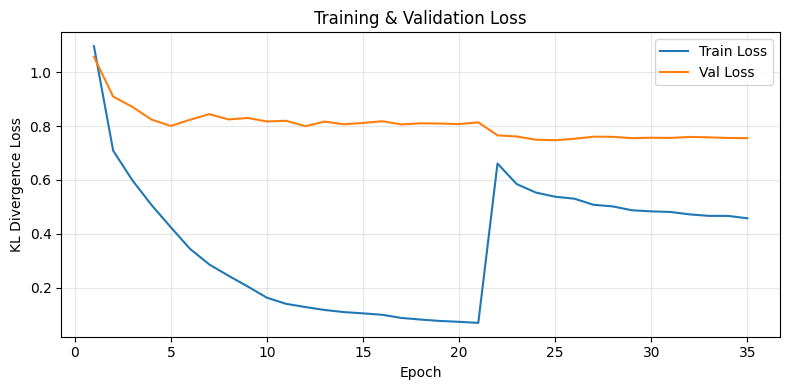

Best val loss: 0.7474 at epoch 25


In [8]:
import matplotlib.pyplot as plt

# If resuming in a fresh session, reload from checkpoint
if not train_losses:
    ckpt = torch.load(latest_path, map_location="cpu")
    train_losses = ckpt.get("train_losses", [])
    val_losses   = ckpt.get("val_losses", [])

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best val loss: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses)) + 1}")

## Camera Testing (Local)

> **Run this cell with a local Python kernel**, not on Colab.
> Download `best.pth` from your Google Drive `color_model_checkpoints/` folder into `models/` in your project root.

Press **q** to quit the camera window.

In [ ]:
import os, cv2, torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_PATH = os.path.join(os.path.dirname(os.path.abspath(".")), "models", "best.pth")
COLOR_CLASSES = [
    "red", "orange", "yellow", "green", "blue",
    "violet", "purple", "white", "gray", "black",
    "pink", "brown", "olive",
]

# ── Load model ───────────────────────────────────────────────────────────────
model = models.resnet50()
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.fc.in_features, len(COLOR_CLASSES)),
)
ckpt = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

infer_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── Camera loop ──────────────────────────────────────────────────────────────
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Cannot open camera")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Center-crop a square region
    h, w = frame.shape[:2]
    side = min(h, w)
    y0, x0 = (h - side) // 2, (w - side) // 2
    crop = frame[y0:y0 + side, x0:x0 + side]

    # Inference
    rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    tensor = infer_transform(rgb).unsqueeze(0)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1).squeeze().numpy()

    # Draw top-5 predictions
    display = frame.copy()
    ranked = sorted(zip(COLOR_CLASSES, probs), key=lambda x: -x[1])
    y_off = 30
    for cls, prob in ranked[:5]:
        text = f"{cls}: {prob * 100:.1f}%"
        cv2.putText(display, text, (10, y_off), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        y_off += 30

    # Draw crop rectangle on display
    cv2.rectangle(display, (x0, y0), (x0 + side, y0 + side), (0, 255, 0), 2)
    cv2.imshow("Color Detection", display)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()